In [4]:
# Importing the important libraries

import numpy as np
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt

# Modelling
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
import warnings

In [10]:
# Import csv data as dataframe
df = pd.read_csv("data/stud.csv")
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [11]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [14]:
X = df.drop(columns = ['math_score'], axis = 1 )

In [15]:
X.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,74
1,female,group C,some college,standard,completed,90,88
2,female,group B,master's degree,standard,none,95,93
3,male,group A,associate's degree,free/reduced,none,57,44
4,male,group C,some college,standard,none,78,75


In [12]:
print("Categories in 'gender' variable: ", end = " ")
print(df['gender'].unique())

print("Categories in 'race_ethnicity variable: ", end = " ")
print(df['race_ethnicity'].unique())

print("Categories in 'parental_level_of_education' variable: ",end = " ")
print(df['parental_level_of_education'].unique())

print("Categories in 'lunch' variable: ", end = " ")
print(df['lunch'].unique())

print("Categories in 'test_preparation_course' variable: ", end = " ")
print(df['test_preparation_course'].unique())



Categories in 'gender' variable:  ['female' 'male']
Categories in 'race_ethnicity variable:  ['group B' 'group C' 'group A' 'group D' 'group E']
Categories in 'parental_level_of_education' variable:  ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
Categories in 'lunch' variable:  ['standard' 'free/reduced']
Categories in 'test_preparation_course' variable:  ['none' 'completed']


In [16]:
y = df['math_score']

In [17]:
y.head()

0    72
1    69
2    90
3    47
4    76
Name: math_score, dtype: int64

In [18]:
# Creating column transformer with 3 types of transformers

num_features = X.select_dtypes(exclude = 'object').columns
cat_features = X.select_dtypes(include = 'object').columns

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

numeric_transformer = StandardScaler()
oh_transformer = OneHotEncoder()

preprocessor = ColumnTransformer(
    [
        ("OneHotEncoder", oh_transformer, cat_features),
        ("StandardScaler", numeric_transformer, num_features)
    ]
)



In [19]:
X=preprocessor.fit_transform(X)

In [20]:
X.shape

(1000, 19)

In [21]:
# separate dataset for train and test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 46)
X_train.shape, X_test.shape

((800, 19), (200, 19))

#### Create an Evaluate Function to give all metrics after model Training

In [22]:
def evaluate_model(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse= mean_squared_error(true, predicted)
    rmse = np.sqrt(mean_squared_error(true, predicted))
    r2_square= r2_score(true, predicted)
    return mae, rmse, r2_square

In [24]:
models = {
    "Linear Regression" : LinearRegression(),
    "Lasso" : Lasso(),
    "Ridge" : Ridge(),
    "K-Neighbors Regressor": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor(),
    "XGB Regressor" : XGBRegressor(),
    "CatBoosting Regressor" : CatBoostRegressor(verbose = False),
    "Adaboost Regressor": AdaBoostRegressor()
}

model_list= []
r2_list = []

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train, y_train)  #train the model
    
    # make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    #Evaluate train test datasets
    model_train_mae, model_train_rmse, model_train_r2 = evaluate_model(y_train, y_train_pred)
    model_test_mae, model_test_rmse, model_test_r2 = evaluate_model(y_test, y_test_pred)
    
    
    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])
    
    print("Model performance for Training set")
    print("- Root mean squared error: {:.4f}".format(model_train_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_train_mae))
    print("- R2 Score: {:.4f}".format(model_train_r2))
    
    print("-"*30)
    
    print("Model performance for testing set")
    print("- Root mean squared error: {:.4f}".format(model_test_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_test_mae))
    print("- R2 Score: {:.4f}".format(model_test_r2))
    r2_list.append(model_test_r2)    
    print("="*30)
    print('\n')
    

Linear Regression
Model performance for Training set
- Root mean squared error: 5.2701
- Mean Absolute Error: 4.2313
- R2 Score: 0.8803
------------------------------
Model performance for testing set
- Root mean squared error: 5.5587
- Mean Absolute Error: 4.3138
- R2 Score: 0.8598


Lasso
Model performance for Training set
- Root mean squared error: 6.5514
- Mean Absolute Error: 5.1639
- R2 Score: 0.8150
------------------------------
Model performance for testing set
- Root mean squared error: 6.5574
- Mean Absolute Error: 5.1795
- R2 Score: 0.8049


Ridge
Model performance for Training set
- Root mean squared error: 5.2703
- Mean Absolute Error: 4.2297
- R2 Score: 0.8803
------------------------------
Model performance for testing set
- Root mean squared error: 5.5599
- Mean Absolute Error: 4.3153
- R2 Score: 0.8598


K-Neighbors Regressor
Model performance for Training set
- Root mean squared error: 5.9068
- Mean Absolute Error: 4.7003
- R2 Score: 0.8496
--------------------------

In [26]:
pd.DataFrame(list(zip(model_list, r2_list)), columns = ['Model Name', 'R2_Score']).sort_values(by=["R2_Score"], ascending = False)

,Model Name,R2_Score
0,Linear Regression,0.859825
2,Ridge,0.859761
5,Random Forest Regressor,0.843653
7,CatBoosting Regressor,0.837697
8,Adaboost Regressor,0.820013
6,XGB Regressor,0.819574
1,Lasso,0.804926
3,K-Neighbors Regressor,0.783573
4,Decision Tree,0.737603


#### Linear Regression

In [27]:
lin_model = LinearRegression(fit_intercept= True)
lin_model = lin_model.fit(X_train, y_train)
y_pred = lin_model.predict(X_test)
score = r2_score(y_test, y_pred)*100
print("Accuracy of the model %.2f" %score)

Accuracy of the model 85.98


### Plot y_pred and y_test

Text(0, 0.5, 'Predicted')

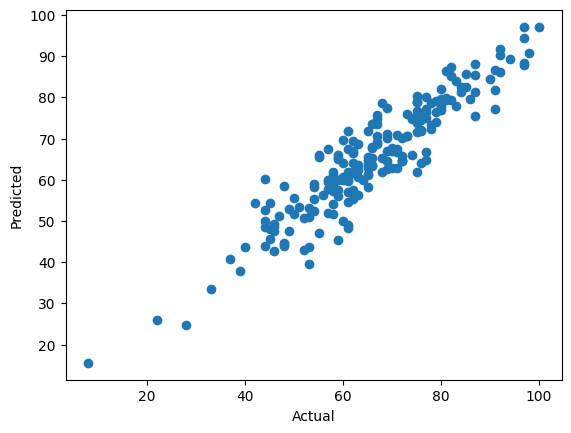

In [28]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")

<Axes: xlabel='math_score'>

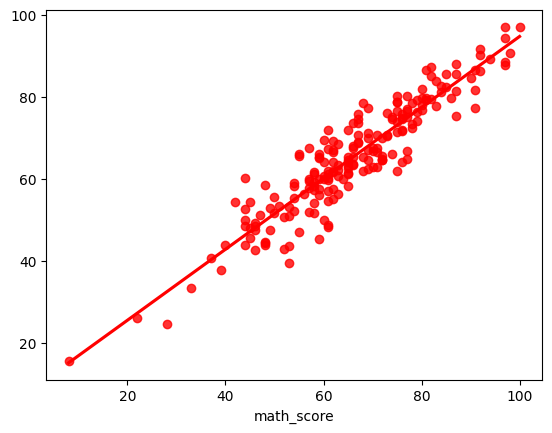

In [29]:
sns.regplot(x=y_test, y=y_pred, ci = None, color = 'red')

#### Difference between Actual and Predicted Values

In [31]:
pred_df = pd.DataFrame({"Actual Values": y_test, "Predicted_values": y_pred, "Difference": y_test-y_pred})
pred_df

,Actual Values,Predicted_values,Difference
576,61,54.666439,6.333561
629,44,43.842960,0.157040
557,61,67.413418,-6.413418
641,74,74.705409,-0.705409
677,70,66.933666,3.066334
...,...,...,...
330,71,67.522747,3.477253
509,86,79.651578,6.348422
173,63,62.246341,0.753659
273,65,64.021577,0.978423
